In [1]:
%pip install imbalanced-learn
%pip install shap

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import glob
import time
import keras
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from joblib import dump, load
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from matplotlib.pyplot import *
from keras.models import Sequential
from sklearn.model_selection import train_test_split
from keras import Model, Input, layers, optimizers
from keras.layers import *
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, classification_report

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

2025-07-24 09:08:15.815367: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-24 09:08:15.831544: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-24 09:08:15.856399: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-24 09:08:15.856428: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-24 09:08:15.871681: I tensorflow/core/platform/cpu_feature_gua

In [3]:
# python.exe -m pip install --upgrade pip

In [4]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  4


2025-07-24 09:08:19.811679: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-24 09:08:19.815320: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-24 09:08:19.820398: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [5]:
# full dataset
path = "swb-s3926387-personal-study"
# path = r'C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/CIC-IDS/CSV-2023/MERGED_CSV'
all_files = glob.glob(path + "/*.csv")
li = []
for filename in all_files:
    df = pd.read_csv(filename, encoding='cp1252', index_col=None, header=0)
    li.append(df)
    print("Read Completed for ", filename)
df = pd.concat(li, axis=0, ignore_index=True)
df.describe()
df.head()
df.info()

Read Completed for  swb-s3926387-personal-study/Merged01.csv
Read Completed for  swb-s3926387-personal-study/Merged02.csv
Read Completed for  swb-s3926387-personal-study/Merged03.csv
Read Completed for  swb-s3926387-personal-study/Merged04.csv
Read Completed for  swb-s3926387-personal-study/Merged05.csv
Read Completed for  swb-s3926387-personal-study/Merged06.csv
Read Completed for  swb-s3926387-personal-study/Merged07.csv
Read Completed for  swb-s3926387-personal-study/Merged08.csv
Read Completed for  swb-s3926387-personal-study/Merged09.csv
Read Completed for  swb-s3926387-personal-study/Merged10.csv
Read Completed for  swb-s3926387-personal-study/Merged11.csv
Read Completed for  swb-s3926387-personal-study/Merged12.csv
Read Completed for  swb-s3926387-personal-study/Merged13.csv
Read Completed for  swb-s3926387-personal-study/Merged14.csv
Read Completed for  swb-s3926387-personal-study/Merged15.csv
Read Completed for  swb-s3926387-personal-study/Merged16.csv
Read Completed for  swb-

In [6]:
print(df.columns)
print(df["Label"].value_counts())
print(df.shape)

Index(['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
       'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
       'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
       'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count',
       'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP',
       'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max',
       'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label'],
      dtype='object')
Label
DDOS-ICMP_FLOOD            6893259
DDOS-UDP_FLOOD             5181027
DDOS-TCP_FLOOD             4306086
DDOS-PSHACK_FLOOD          3920372
DDOS-SYN_FLOOD             3886130
DDOS-RSTFINFLOOD           3872808
DDOS-SYNONYMOUSIP_FLOOD    3445659
DOS-UDP_FLOOD              3177323
DOS-TCP_FLOOD              2558256
DOS-SYN_FLOOD              1942176
BENIGN                     1051373
MIRAI-GREETH_FLOOD          949381
MIRAI-UDPPLAIN              852695
MIRAI-GREIP_FLOOD   

Many network intrusion datasets (like CICIoT2023) contain very specific attack names (e.g., 'DDoS-UDP_Flood', 'SqlInjection'). These are too granular for efficient model training and analysis, so we group them into broader categories, such as 'DDoS', 'DoS', 'Recon', etc.

<h3> Why this is useful </h3>
    <li> Reduces label complexity (from 30+ labels to ~6–7 categories).</li>
    <li> Helps balance the dataset more evenly.</li>
    <li> Simplifies the classification problem for your ML model.</li>

<h3> Example: </h3>
<p>If your original data had this:</p>
<P>Label</p>
<ul>
    <li>DDoS-UDP_Flood</li>
    <li>DDoS-ACK_Fragmentation</li>
    <li>SqlInjection</li>
</ul>

<p>It will become:</p>
<p>Label</p>
<ul>
    <li>DDoS</li>
    <li>DDoS</li>
    <li>Web_based</li>
</ul>

In [7]:
DDoS = ['DDOS-ACK_FRAGMENTATION',     
        'DDOS-UDP_FLOOD',       
        'DDOS-SLOWLORIS',               
        'DDOS-ICMP_FLOOD',        
        'DDOS-RSTFINFLOOD',    
        'DDOS-PSHACK_FLOOD',        
        'DDOS-HTTP_FLOOD',              
        'DDOS-UDP_FRAGMENTATION',     
        'DDOS-TCP_FLOOD',  
        'DDOS-SYN_FLOOD',        
        'DDOS-SYNONYMOUSIP_FLOOD',    
        'DDOS-ICMP_FRAGMENTATION']

DoS = ['DOS-UDP_FLOOD',    
       'DOS-TCP_FLOOD',    
       'DOS-SYN_FLOOD',    
       'DOS-HTTP_FLOOD']

Spoofing = ['MITM-ARPSPOOFING',     
            'DNS_SPOOFING']

Brute_force = ['DICTIONARYBRUTEFORCE']

Recon = ['RECON-HOSTDISCOVERY', 
         'RECON-OSSCAN',     
         'RECON-PORTSCAN',               
         'RECON-PINGSWEEP',         
         'VULNERABILITYSCAN']

Web_based = ['SQLINJECTION',        
             'BROWSERHIJACKING',         
             'COMMANDINJECTION',       
             'XSS',         
             'BACKDOOR_MALWARE',          
             'UPLOADING_ATTACK']

Mirai = ['MIRAI-GREETH_FLOOD',     
         'MIRAI-UDPPLAIN',     
         'MIRAI-GREIP_FLOOD']



def classify_attacks(data):
    data['Label'].replace(DDoS,'DDoS',inplace=True)
    data['Label'].replace(DoS,'DoS',inplace=True)
    data['Label'].replace(Spoofing,'Spoofing',inplace=True)
    data['Label'].replace(Brute_force,'Brute_Force',inplace=True)
    data['Label'].replace(Recon,'Recon',inplace=True)
    data['Label'].replace(Web_based,'Web_based',inplace=True)
    data['Label'].replace(Mirai,'Mirai',inplace=True)
classify_attacks(df)

print(df["Label"].value_counts())
print(df.shape)

Label
DDoS           32536197
DoS             7746554
Mirai           2521731
BENIGN          1051373
Recon            661121
Spoofing         465937
Web_based         23799
Brute_Force       12522
Name: count, dtype: int64
(45019243, 40)


Non-numerical data is incomprehensible to machine learning modules. To avoid issues later on, the data should be arranged numerically. The answer to this problem is to convert all text values to numerical form.

In [8]:
df.drop_duplicates(keep='first', inplace = True)
df.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
df.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
df.reset_index(drop=True, inplace=True)
print("Read {} rows.".format(len(df)))
print(df['Label'].value_counts())    # Shows how many samples exist for each class (now as numbers). This is useful to check for class imbalance.

labelencoder = LabelEncoder()    # This creates a LabelEncoder from sklearn, which is used to convert string labels into integers
df['Label'] = labelencoder.fit_transform(df['Label'])    # Encodes the string class labels into integer labels and replaces the original Label column with them.
print(df.shape)
print(df['Label'].value_counts())    # Shows how many samples exist for each class (now as numbers). This is useful to check for class imbalance.

Read 20833013 rows.
Label
DDoS           12122114
DoS             4178464
Mirai           2359183
BENIGN          1047308
Recon            654062
Spoofing         435662
Web_based         23700
Brute_Force       12520
Name: count, dtype: int64
(20833013, 40)
Label
2    12122114
3     4178464
4     2359183
0     1047308
5      654062
6      435662
7       23700
1       12520
Name: count, dtype: int64


<Axes: >

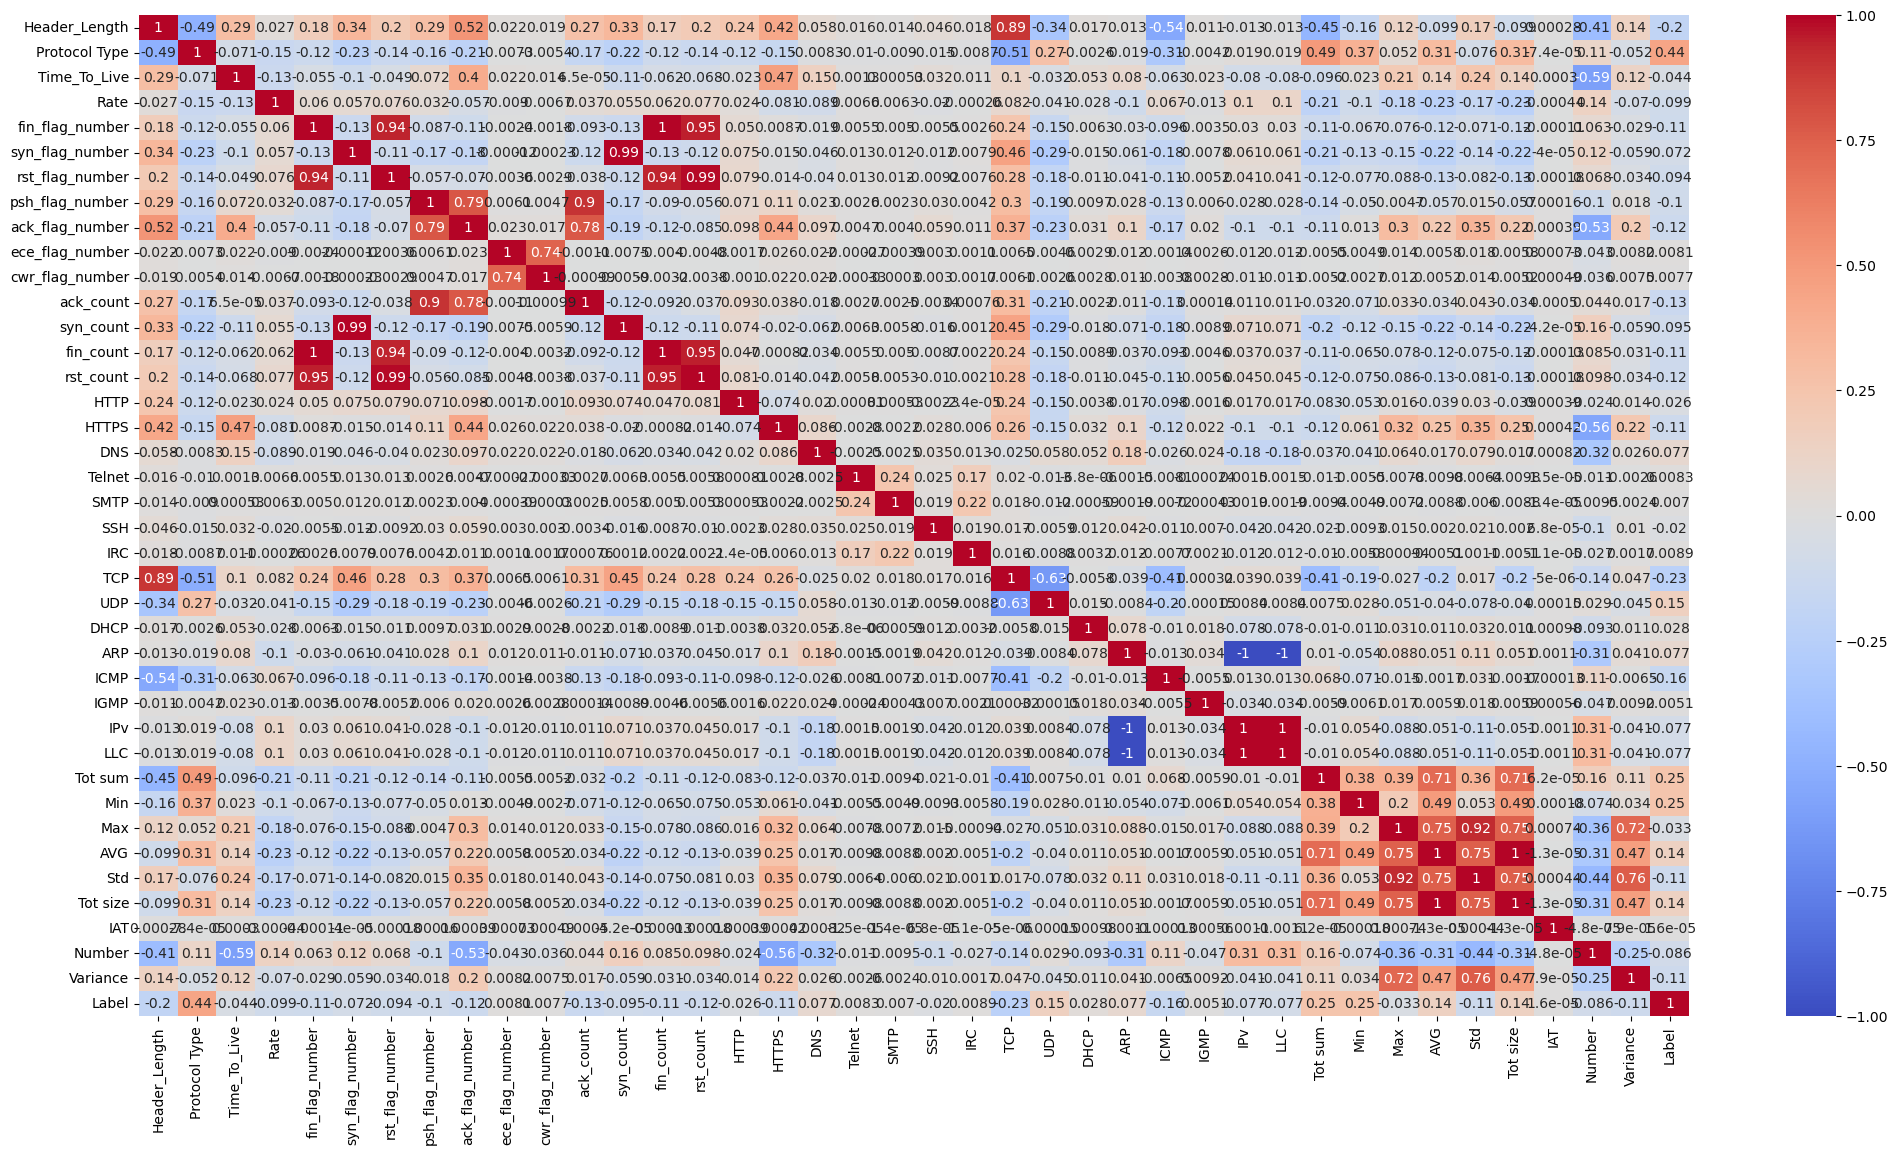

In [9]:
# Before correlation filter
plt.figure(figsize=(25,13))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [10]:
df = df.drop(columns=['fin_count', 'fin_flag_number', 'rst_count', 'rst_flag_number', 'syn_count'])

<Axes: >

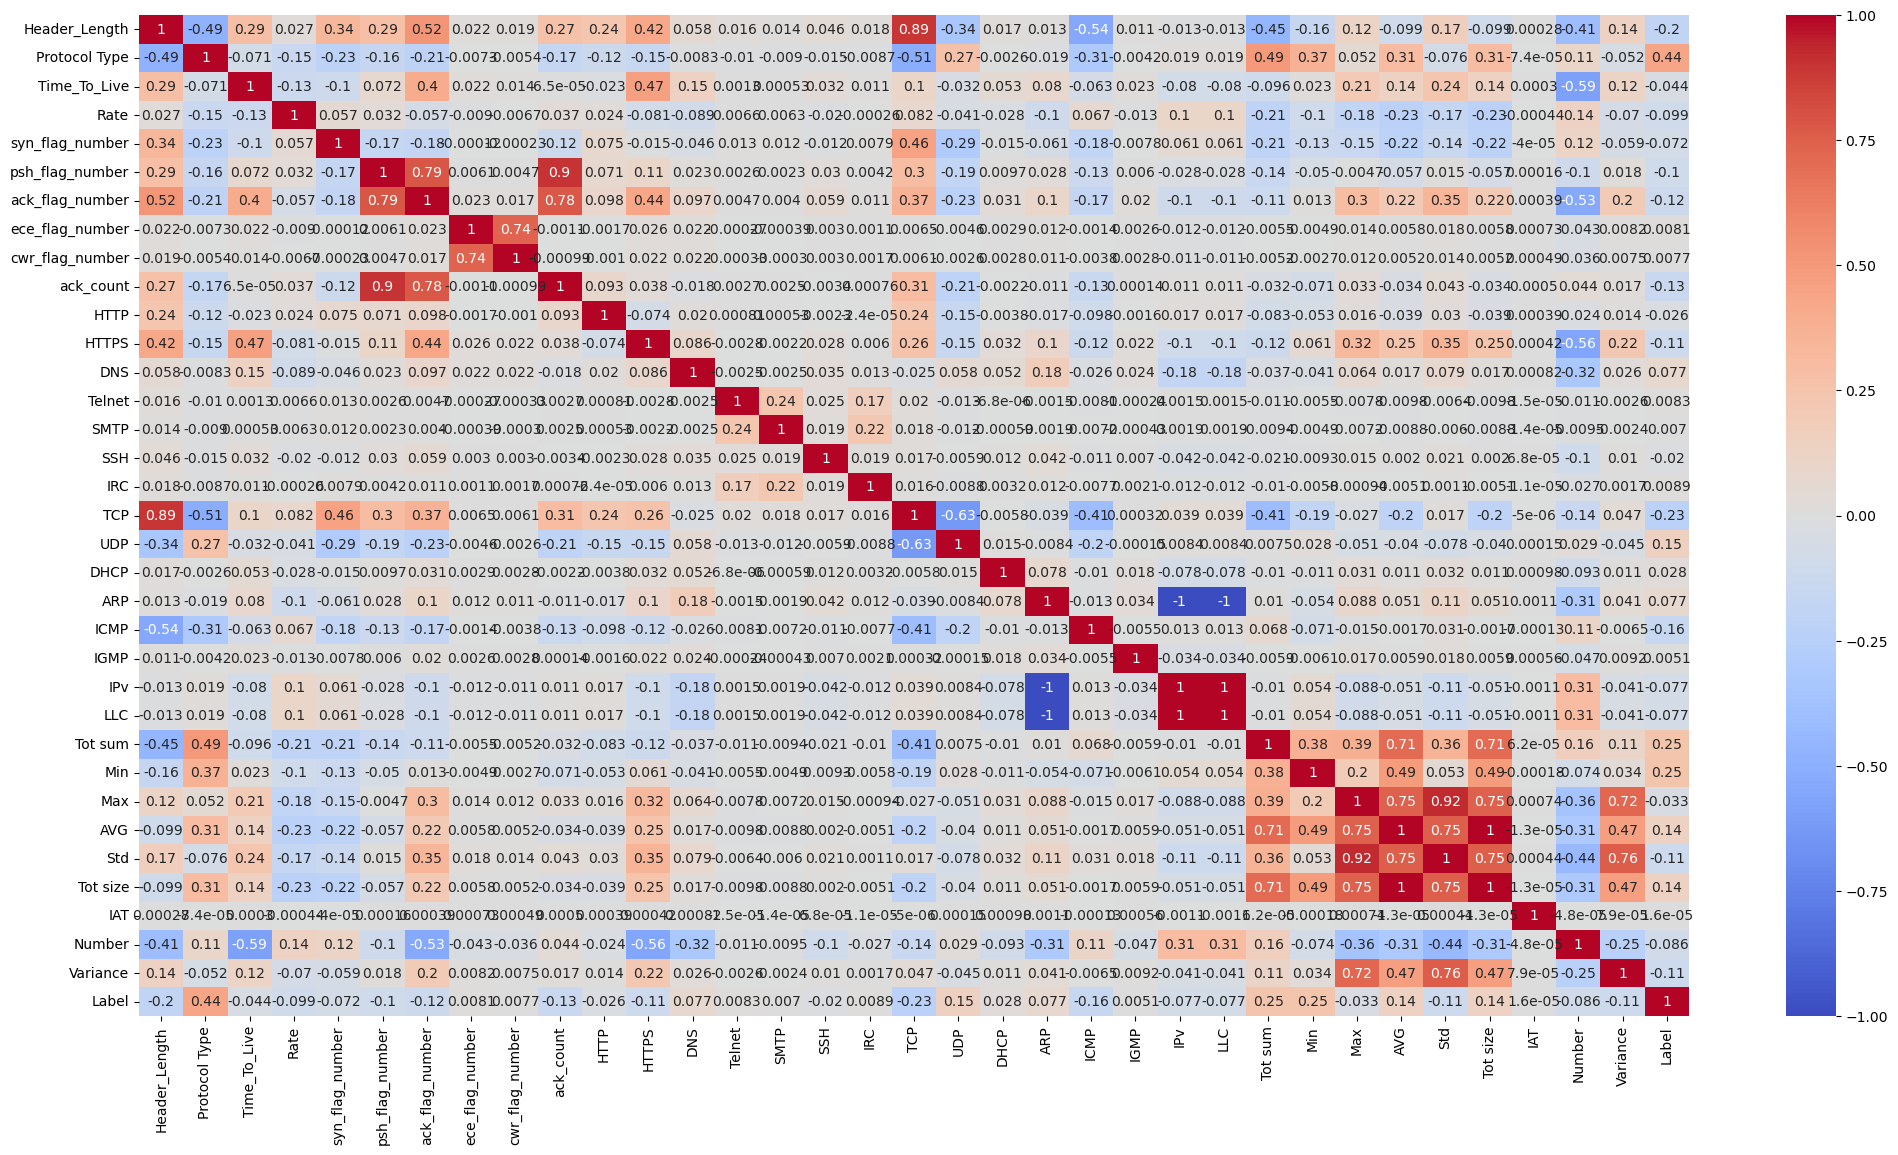

In [11]:
# After correlation filter
plt.figure(figsize=(25,13))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [12]:
data_np = df.to_numpy(dtype="float32")      # Converts the entire DataFrame into a NumPy array with float32 data type—faster and more efficient for ML model input.
#drop inf values
data_np = data_np[~np.isinf(data_np).any(axis=1)]   # Removes any rows that have infinite values (inf) across any column. This ensures clean numeric data for training

In [13]:
rows = data_np.shape[0]
limit = round(rows*50/100) # split the dataset into 2 part: 80% for train and val; 20% to test
train_val = data_np[1:limit] 	

test = data_np[limit:rows]

In [14]:
print(train_val.shape)

(10416505, 35)


In [15]:
# X = train_val[:, :-1] 
# Y = train_val[:, -1]

In [16]:
X = train_val[:, :-1]      # This selects all features (columns except the last one)—i.e., your input data for the model.
enc = OneHotEncoder()     # Initializes a OneHotEncoder which is used to encode integer class labels into one-hot encoded vectors.
                          # For example: if i have [0, 1, 2], One-hot encoding becomes: [1,0,0]
                                                                                       #[0,1,0]
                                                                                       #[0,0,1]
Y = enc.fit_transform(train_val[:, -1].reshape(-1, 1)).toarray()    # data_np[:, -1] gets the last column = labels (in integer form).
                                                                    # reshape(-1, 1) reshapes it into a column vector.
                                                                    # fit_transform(...) fits and transforms to one-hot encoded format.
                                                                    # .toarray() converts it from sparse to dense array.

                                                                    # Now Y contains labels in one-hot format, ready for training in multiclass classification models like neural networks.
#  Final Result:
#   X: Cleaned, scaled feature matrix.
#   Y: One-hot encoded label matrix.
#Ready to be split into training/testing and fed into models like CNN, LSTM, etc.

In [17]:
print(Y.shape)
print(X.shape)

(10416505, 8)
(10416505, 34)


In [18]:
# This block is created to keep track with the under or over sampling
# print(Y)
decoded_Y = np.argmax(Y,axis=1)
# print(decoded_Y)
labels = decoded_Y.astype(int) # data_np default as float, float can't work with the inverse transform

# print(int(label_series[0]))
# print(labelencoder.inverse_transform([int(label_series[0])])[0])

decoded_labels = labelencoder.inverse_transform(labels) # Inverse transform the whole array
                                                        # inverse_transform() accepts a NumPy array, so it internally uses vectorized operations

label_series = pd.Series(decoded_labels) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
sample_limit = label_series.value_counts()[2]
print(label_series.value_counts())

DDoS           6200508
DoS            2079992
Mirai          1123843
BENIGN          487094
Recon           304803
Spoofing        203429
Web_based        11015
Brute_Force       5821
Name: count, dtype: int64


In [19]:
# Unbalance handling

# Under sampling
undersample = RandomUnderSampler(sampling_strategy={2:sample_limit, 3:sample_limit}) # if the strategy ='all' - normal undersample; if it a dict then the key is the name of the label and the value is 
                                                                            # the target undersample - in this case '2' is the name of the 'DDOS' after encoded
X_under, y_under = undersample.fit_resample(X, Y)

# Over sampling
sm = SMOTE()
X_sm, Y_sm = sm.fit_resample(X_under, y_under)

print(Y_sm.shape)
print(X_sm.shape)

(8990744, 8)
(8990744, 34)


In [20]:
# Under sampling only
# undersample = RandomUnderSampler(sampling_strategy='all')   # if the strategy ='all' - normal undersample; if it a dict then the key is the name of the label and the value is 
#                                                             # the target undersample - in this case '2' is the name of the 'DDOS' after encoded
# X_sm, Y_sm = undersample.fit_resample(X, Y)

In [21]:
# This block is created to keep track with the under or over sampling
# print(Y)
decoded_Y = np.argmax(Y_sm,axis=1)
# print(decoded_Y)
labels = decoded_Y.astype(int) # data_np default as float, float can't work with the inverse transform

# print(int(label_series[0]))
# print(labelencoder.inverse_transform([int(label_series[0])])[0])

decoded_labels = labelencoder.inverse_transform(labels) # Inverse transform the whole array
                                                        # inverse_transform() accepts a NumPy array, so it internally uses vectorized operations

label_series = pd.Series(decoded_labels) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(label_series.value_counts())

BENIGN         1123843
Brute_Force    1123843
DDoS           1123843
DoS            1123843
Mirai          1123843
Recon          1123843
Spoofing       1123843
Web_based      1123843
Name: count, dtype: int64


In [22]:
X_test = test[:, :-1]
enc = OneHotEncoder()
Y_test = enc.fit_transform(test[:, -1].reshape(-1, 1)).toarray()

# X_test = test[:, :-1] 
# Y_test = test[:, -1]

# print(X_test)
# print(Y_test)

What it does:
This scales (standardizes) your feature matrix X.
Specifically:
<ul>
    <li>StandardScaler() creates an object that standardizes the features.
    <li>Standardization means: for each feature/column in X, it will subtract the mean and divide by the standard deviation.
</ul>
Mathematically for each feature:

𝑋_scaled = (𝑋 − mean(𝑋)) / std(𝑋)
 
As a result:
<ul>
    <li>The new mean of each feature = 0.
    <li>The new standard deviation of each feature = 1.
</ul>

Why StandardScale important?
<ul>
    <li>Machine Learning algorithms (especially neural networks) work better when input features are on the same scale.
    <li>If features have very different scales (e.g., some from 0–1, some from 0–10,000), the model can struggle to converge or be biased toward features with larger numbers.
    <li>Standardization makes gradient descent faster and model training more stable.
</ul>

In simple terms:
<ul>
    <li>Before: your features might look like [50, 10000, 3.2, 0.001]
    <li>After StandardScaler: numbers become something like [0.12, 2.5, -1.0, -0.3]
    <li>Now all features are centered around 0 and have similar ranges, which helps the model learn better!
</ul>

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sm)

In [24]:
X_test_scaled = scaler.fit_transform(X_test)

<div>X_train = X_train.reshape(X_train.shape[0], _features, 1).astype('float32')
<div>X_test = X_test.reshape(X_test.shape[0], _features, 1).astype('float32')
<div></div>
What it does:
<ul>
    <li>Reshapes the training and testing data.
    <li>Originally X_train shape = (num_samples, num_features)
    <li>After reshaping: (num_samples, num_features, 1)
</ul>

Why add this extra dimension?

👉 Because you are feeding the data into a 1D Convolutional Neural Network (Conv1D), and Conv1D expects 3D input:

(samples, features, channels)

Here channels = 1 because your features are just single numbers, not multi-channel like RGB images (where channels = 3).
Also, .astype('float32') just ensures the data type is correct (TensorFlow prefers float32).

In simple words:
<table>
    <tr>
        <th>Before</th>
        <th>After</th>
    </tr>
    <tr>
        <td>2D: (number of samples, number of features)</td>
        <td>3D: (number of samples, number of features, 1 channel)</td>
    </tr>
</table>

You split the data, prepare it for the neural network, and make sure the format is correct!

In [25]:
# Split the data set into training and testing
X_train, X_val, Y_train, Y_val = train_test_split(
    X_scaled, Y_sm, test_size=0.25, random_state=33, shuffle=True)

_features = X.shape[1]  # _features stores how many input features there are (i.e., the number of columns in X).
n_classes = Y.shape[1]  # n_classes stores how many output classes there are (i.e., how many unique categories in Y after one-hot encoding).

# The code below only needed if we use CNN. CNN require a 3D input
# X_train = X_train.reshape(X_train.shape[0], _features, 1).astype('float32')
# X_val = X_val.reshape(X_val.shape[0], _features, 1).astype('float32')

In [26]:
# dump(X_train, 'X_train.joblib')
# dump(X_val, 'X_val.joblib')
# dump(Y_train, 'Y_train.joblib')
# dump(Y_val, 'Y_val.joblib')

In [27]:
print(_features)
print(n_classes)

34
8


Summary Table:
<table>
    <tr>
        <th>Layer</th>
        <th>Purpose</th>
        <th>Key Params</th>
    </tr>
    <tr>
        <td>Input</td>
        <td>Define input shape</td>
        <td>(_features, 1)</td>
    </tr>
    <tr>
        <td>Conv1D</td>
        <td>Learn local patterns (small)</td>
        <td>256 filters, size 3</td>
    </tr>
    <tr>
        <td>MaxPooling</td>
        <td>Reduce data size, keep important info</td>
        <td>pool size = 3</td>
    </tr>
    <tr>
        <td>Conv1D</td>
        <td>Deeper pattern extraction (compressed)</td>
        <td>128 filters, size 3</td>
    </tr>
    <tr>
        <td>UpSampling</td>
        <td>Expand data back to larger size</td>
        <td>size = 3</td>
    </tr>
    <tr>
        <td>Conv1D</td>
        <td>Refine expanded features</td>
        <td>256 filters, size 3</td>
    </tr>
</table>
In simple words:
<div>It's like zooming into small parts, compressing them into important features, and then reconstructing useful information to make a classification later.

In [28]:
# # CNN model
# Convolutional Encoder
# input_img = Input(shape=(_features, 1)) # This defines the input shape of your model.
#                                         # _features is the number of features (columns) in your data.
#                                         # 1 means only 1 channel (like grayscale image instead of RGB).
# # It tells the model: ➔ "Expect input data shaped like (features, 1)

# conv_1 = Convolution1D(1024, 6, activation='relu')(input_img)  # Extract small patterns from the input (3 features wide), and learn 256 different kinds of patterns.
# normal_1 = layers.BatchNormalization()(conv_1)
# pool_1 = MaxPooling1D(2)(normal_1)    # Downsamples the feature map (makes it smaller and faster), while preserving important signals.

# # Bottleneck
# conv_2 = Convolution1D(512, 6, activation='relu')(pool_1)  # Further compress and extract deeper features from the downsampled signal.
# normal_2 = layers.BatchNormalization()(conv_2)

# # Decoder
# up_1 = UpSampling1D(3)(normal_2)  # Recover some of the original data structure after compression.
# conv_3 = Convolution1D(1024, 6, activation='relu')(up_1)  # Refines the expanded feature map, helping recover meaningful patterns after upsampling.

# flatten = Flatten()(conv_3)

In [29]:
# Autoencoder
# encode_1 = Dense(1024, activation='relu')(flatten)
# encode_2 = Dense(512, activation='relu')(encode_1)
# encode_3 = Dense(256, activation='relu')(encode_2)
# bottle = Dense(128, activation='relu')(encode_3)
# decode_1 = Dense(256, activation='relu')(bottle)
# decode_2 = Dense(512, activation='relu')(decode_1)
# decode_3 = Dense(1024, activation='relu')(decode_2)

# softmax = Dense(n_classes, activation='softmax', name='classification')(decode_3)

# model = Model(inputs=input_img, outputs=softmax)

In [30]:
model = Sequential([
    Input(shape=(_features,1)),

    # CNN layer structure
    Convolution1D(1024, 6, activation='relu'),
    layers.BatchNormalization(),
    MaxPooling1D(2),
    Convolution1D(512, 6, activation='relu'),
    layers.BatchNormalization(),
    UpSampling1D(3),
    Convolution1D(1024, 6, activation='relu'),
    Flatten(), # Maybe when we don't use lstm
    
    # LSTM layer structure
    # LSTM(512, return_sequences=False),
    # Dense(256, activation='relu'),
    
    # FNN layer structure
    # Dense(256, activation='relu'), # Already have a Dense above
    # Dropout(0.3),
    # Dense(128, activation='relu'),
    # Dropout(0.3),
    # Dense(n_classes, activation='softmax')

    # Autoencoder
    Dense(1024, activation='relu'),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),   # bottleneck
    Dense(256, activation='relu'),
    Dense(512, activation='relu'),
    Dense(1024, activation='relu'),

    # Classification layer
    Dense(n_classes, activation='softmax'),  # Softmax for multiclass, Sigmoid for binary, both use as output layer
])

2025-07-24 09:19:25.514931: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-24 09:19:25.516511: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-24 09:19:25.518004: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 29, 1024)       │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 29, 1024)       │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 9, 512)         │     3,146,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 9, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 27, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 22, 1024)       │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 22528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    23,069,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │         8,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,763,144 (117.35 MB)

 Trainable params: 30,760,072 (117.34 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [32]:
opt = optimizers.Adam(learning_rate=0.0001)
model.compile(loss='categorical_crossentropy',optimizer=opt, metrics=['accuracy'])
early_stop_callback = keras.callbacks.EarlyStopping(monitor='loss', patience=5)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                  patience=3, min_lr=0.0001)

In [ ]:
start_fit = time.time()
history = model.fit(X_train, Y_train,
                              batch_size=128,
                              epochs=10,
                              verbose=True,
                              validation_data=(X_val, Y_val))    

end_fit = time.time()
fit_time = end_fit - start_fit
print("fit time: {:.2f} seconds".format(fit_time))  

Epoch 1/10


I0000 00:00:1753348771.618102   15719 service.cc:145] XLA service 0x7f9cb801bcd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753348771.618128   15719 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1753348771.618131   15719 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1753348771.618133   15719 service.cc:153]   StreamExecutor device (2): Tesla T4, Compute Capability 7.5
I0000 00:00:1753348771.618135   15719 service.cc:153]   StreamExecutor device (3): Tesla T4, Compute Capability 7.5
2025-07-24 09:19:32.276461: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-07-24 09:19:33.998556: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
2025-07-24 09:19:45.398832: E external/local_xla/xla/service/slow

    5/52681 ━━━━━━━━━━━━━━━━━━━━ 25:40 29ms/step - accuracy: 0.2019 - loss: 2.0276 

I0000 00:00:1753348798.695471   15719 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


52681/52681 ━━━━━━━━━━━━━━━━━━━━ 1687s 31ms/step - accuracy: 0.7170 - loss: 0.6687 - val_accuracy: 0.7937 - val_loss: 0.4913
Epoch 2/10
52681/52681 ━━━━━━━━━━━━━━━━━━━━ 1645s 31ms/step - accuracy: 0.8054 - loss: 0.4606 - val_accuracy: 0.8216 - val_loss: 0.4219
Epoch 3/10
52681/52681 ━━━━━━━━━━━━━━━━━━━━ 1644s 31ms/step - accuracy: 0.8304 - loss: 0.3961 - val_accuracy: 0.8393 - val_loss: 0.3757
Epoch 4/10
52681/52681 ━━━━━━━━━━━━━━━━━━━━ 1642s 31ms/step - accuracy: 0.8432 - loss: 0.3618 - val_accuracy: 0.8465 - val_loss: 0.3552
Epoch 5/10
52681/52681 ━━━━━━━━━━━━━━━━━━━━ 1642s 31ms/step - accuracy: 0.8517 - loss: 0.3383 - val_accuracy: 0.8512 - val_loss: 0.3426
Epoch 6/10
52681/52681 ━━━━━━━━━━━━━━━━━━━━ 1639s 31ms/step - accuracy: 0.8580 - loss: 0.3215 - val_accuracy: 0.8551 - val_loss: 0.3332
Epoch 7/10
52681/52681 ━━━━━━━━━━━━━━━━━━━━ 1637s 31ms/step - accuracy: 0.8627 - loss: 0.3085 - val_accuracy: 0.8534 - val_loss: 0.3416
Epoch 8/10
52681/52681 ━━━━━━━━━━━━━━━━━━━━ 1636s 31ms/step

If val loss increases while train loss keeps decreasing, it’s overfitting

In [ ]:
# Assuming 'history' is the result from model.fit()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy Curve')
plt.show()

In [34]:
model_test = model.predict(X_test_scaled)

# Convert softmax predictions to class indices
model_test_labels = np.argmax(model_test, axis=1)

# Convert one-hot encoded y_test to class indices
y_test_labels = np.argmax(Y_test, axis=1)

# Generate the classification report
print(classification_report(y_test_labels, model_test_labels))

325516/325516 ━━━━━━━━━━━━━━━━━━━━ 1161s 4ms/step
              precision    recall  f1-score   support

           0       0.24      0.95      0.38    560214
           1       0.00      0.19      0.01      6699
           2       0.98      0.35      0.52   5921605
           3       0.61      0.09      0.15   2098472
           4       0.91      0.98      0.94   1235340
           5       0.02      0.18      0.04    349259
           6       0.05      0.26      0.09    232233
           7       0.00      0.03      0.01     12685

    accuracy                           0.40  10416507
   macro avg       0.35      0.38      0.27  10416507
weighted avg       0.80      0.40      0.46  10416507



In [ ]:
fitting_time_np = np.array([['Start time', 'End time', 'Fitting time'],
                            [start_fit, end_fit, fit_time]])

fitting_time_np

## Export model and LabelEncoder

In [ ]:
from keras.models import load_model

In [ ]:
model.save("CNN_model_1.keras", save_format="keras")
model.save('CNN_model_2.h5')

In [ ]:
model = load_model("CNN_model_1.keras")

In [ ]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(labelencoder, f)

In [ ]:
with open("label_encoder.pkl", "rb") as f:
    labelencoder = pickle.load(f)

In [ ]:
# test model
import random
data = random.randint(0,len(X_test))
print(data)

segment = X_test[data]
test_data = segment.reshape(1, _features, 1).astype('float32')

### How to use labelencoder
pred = model.predict(test_data)
predicted_class = np.argmax(pred)
original_label = labelencoder.inverse_transform([predicted_class])[0]
print("Predicted class label:", original_label)
original_real_label = labelencoder.inverse_transform([np.argmax(Y_test[data])])[0]
print("Actual class label:", original_real_label)

In [ ]:
# Convert predictions classes to one hot vectors 
pred = np.argmax(pred,axis=1)
# Convert validation observations to one hot vectors
y_test = Y_val.argmax(axis=1)

print(pred.shape)
print(y_test.shape)

score = metrics.accuracy_score(y_test, pred)
rscore = recall_score(y_test, pred, average='weighted')
ascore = precision_score(y_test, pred, average='weighted')
ascore_macro = precision_score(y_test, pred, average='macro')
f1score= f1_score(y_test, pred, average='weighted') #F1 = 2 * (precision * recall) / (precision + recall) for manual

print("Validation score: {}".format(score))
print("Recall score: {}".format(rscore))
print("Precision score: {}".format(ascore))
print("Precision score macro: {}".format(ascore_macro))
print("F1 Measure score: {}".format(f1score))